# Laboratorium 9 - Sieci Rekurencyjne

Na tym laboratorium zapoznamy się z sieciami rekurencyjnymi - jedną z architektur dedykowanych danym sekwencyjnym. Dla danych sekwencyjnych, jednym z naturalnych podejść do modelowania jest założenie, że przetwarzając n-ty krok, możemy udostępnić modelowi pewną reprezentację historii/pamięci/stanu która w kompaktowy sposób przechowuje informację o "wszystkim co działo się wcześniej". W ten sposób zadania upraszcza sobie często np. modelowanie procesami stochastycznymi (założenie własności Markowa w modelu). W kontekście sieci neuronowych, odpowiednikiem takiego podejścia jest właśnie warstwa rekurencyjna: taka, która w n-tym kroku przetwarza n-te wejście i reprezentacje ukrytą z kroku n-1 (historię/stan/pamięć).

Oczywiście z góry warstwo wspomnieć o fakcie, że architektury rekurencyjne obecnie nie są pierwszym wyborem, w pracach state=of-the-art dominuje mechanizm uwagi. Transformery to obecnie podstawa wszystkiego, co kojarzone z sztuczną inteligencją - w szczególności wszelkiej maści "czatów" opartych o LLM (Large Language Models). Ale ich historia to w pierwszej kolejności dodanie mechanizmu uwagi do sieci rekurencyjnych, a dopiero potem spostrzeżenie, że po dodaniu tego mechanizmu, rekurencja nie jest już w zasadzie konieczna (bardzo znana publikacja *Attention Is All You Need*).

 Na tych laboratoriach przyjrzyjmy się warstwom LSTM - najpopularniejszej wersji architektury czysto rekurencyjnej.

# Zbiory danych

Przeprowadzimy test na dwóch zbiorach danych: klasyczny zbiór do analizy sentymentu tekstów (recenzje IMDB), oraz zbiór audio - rozpoznawanie owadów po wydawanych rzez nich odgłosach.

In [1]:
import ssl
import certifi
from tensorflow.keras.datasets import imdb

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz',
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)

In [2]:
print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [3]:
from aeon.datasets import load_classification
X, y = load_classification("InsectWingbeat", extract_path="insect_data")

In [4]:
print(X[0])

[[-0.0005 -0.0003  0.0004 ... -0.0017  0.0014  0.0007]
 [ 0.0004 -0.0116 -0.0111 ... -0.0029  0.0126  0.0128]
 [-0.0005  0.1198  0.1097 ...  0.0277 -0.1244 -0.1282]
 ...
 [ 0.0007 -0.0003  0.0009 ...  0.0075  0.008   0.0045]
 [-0.0008 -0.0086 -0.0084 ... -0.0016  0.0061  0.0065]
 [-0.0008 -0.0086 -0.0084 ... -0.0016  0.0061  0.0065]]


# Wczytywanie danych sekwencyjnych

Dla danych sekwencyjnych, przy przetwarzaniu w batchu pojawia się nowa komplikacja: batch musi być możliwy do "spakowania" w tensorze `batch_size x vector_dimension x sequence_length `, podczas gdy sekwencje w zbiorze uczącym nie muszą być jednakowego rozmiaru. Rozwiązaniem jest padding: dopełnianie tensorów zerami do stałej długości.

W problemach klasyfikacyjnych to powoduje jednak nowy problem: chcemy uzyskać reprezentację do klasyfikacji na końcu właściwej sekwencji, nie po przetworzeniu kilu (nastu/dziesięciu/set) dodatkowych wektorów zer. Implementacje warstw rekurencyjnych w torchu oferują nam rozwiązanie w postaci obiektów PackedSequence. Odpowiednimi funkcjami możemy "spakować" zarówno listę sekencji, jak i tensor już wypadowanych danych z podanymi osobno długościami sekwencji. Podanie takiej paczki na wejści warstwy rekurencyjnej gwarantuje, że warstwa zwróci nam swoją reprezentację na poziomie **ostatniego elementu właściwej sekwencji** (nie biorąc pod uwagę paddingu).

In [5]:
import torch

sequences = [[0,1,2,3],
             [0,1],
             [0]]

packed_sequences = torch.nn.utils.rnn.pack_sequence([torch.tensor(seq) for seq in sequences])
print(packed_sequences)

padded_sequences = torch.nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in sequences])
print(padded_sequences)

packed_padded_sequences = torch.nn.utils.rnn.pack_padded_sequence(padded_sequences, [len(s) for s in sequences])
print(packed_padded_sequences)

PackedSequence(data=tensor([0, 0, 0, 1, 1, 2, 3]), batch_sizes=tensor([3, 2, 1, 1]), sorted_indices=None, unsorted_indices=None)
tensor([[0, 0, 0],
        [1, 1, 0],
        [2, 0, 0],
        [3, 0, 0]])
PackedSequence(data=tensor([0, 0, 0, 1, 1, 2, 3]), batch_sizes=tensor([3, 2, 1, 1]), sorted_indices=None, unsorted_indices=None)


# Zadanie 1

Zaimplementuj obiekty Dataset i DataLoader dla naszych zbiorów danych w wariantach zwracających zarówno obiekt PackedSequences, jak i prosty tensor z  wypadowanym zerami batchem.

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

MAX_LEN    = 300
VOCAB_SIZE = max(max(s) for s in x_train) + 1 


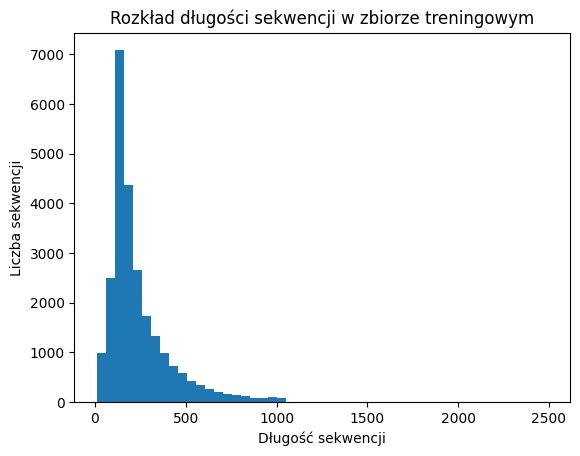

In [7]:
lengths = [len(seq) for seq in x_train]
plt.hist(lengths, bins=50)
plt.xlabel('Długość sekwencji')
plt.ylabel('Liczba sekwencji')
plt.title('Rozkład długości sekwencji w zbiorze treningowym')
plt.show()

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pack_sequence

class IMDBDataset(Dataset):
    def __init__(self, sequences, labels, max_len=None):
        self.labels = torch.tensor(labels, dtype=torch.float32)
        if max_len:
            sequences = [s[:max_len] for s in sequences]
        self.sequences = [torch.tensor(s, dtype=torch.long) for s in sequences]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# tensorowe wypelnienie zerazmi
def collate_padded(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    return padded, lengths, torch.stack(labels)

# obiekty packed sequence
def collate_packed(batch):
    seqs, labels = zip(*batch)
    indices = sorted(range(len(seqs)), key=lambda i: len(seqs[i]), reverse=True)
    # sortowanie malejaco po dlugosci sekwencji
    seqs_sorted   = [seqs[i]   for i in indices]
    labels_sorted = [labels[i] for i in indices]
    packed = pack_sequence(seqs_sorted)
    return packed, torch.stack(labels_sorted)


train_ds = IMDBDataset(x_train, y_train, max_len=MAX_LEN)
test_ds  = IMDBDataset(x_test,  y_test,  max_len=MAX_LEN)

train_loader_pad = DataLoader(train_ds, batch_size=64, shuffle=True,  collate_fn=collate_padded)
test_loader_pad  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_padded)

train_loader_pack = DataLoader(train_ds, batch_size=64, shuffle=True,  collate_fn=collate_packed)
test_loader_pack  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_packed)

batch_pad, lengths, labels = next(iter(train_loader_pad))
print(f"[Padded]  batch shape: {batch_pad.shape}, lengths: {lengths[:5]}")

batch_pack, labels_pack = next(iter(train_loader_pack))
print(f"[Packed]  {batch_pack}")


[Padded]  batch shape: torch.Size([64, 300]), lengths: tensor([300, 300, 176, 224, 127])
[Packed]  PackedSequence(data=tensor([ 1,  1,  1,  ..., 10, 10, 10]), batch_sizes=tensor([64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64,
        64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 63, 63, 63, 63, 63, 63, 63,
        63, 63, 63, 63, 63, 63, 63, 63, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62,
        62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 61, 61, 61,
        61, 61, 61, 61, 61, 60, 59, 59, 59, 59, 59, 58, 58, 58, 58, 58, 58, 58,
        58, 58, 58, 58, 58, 58, 58, 58, 57, 57, 57, 57, 56, 56, 56, 55, 54, 54,
        53, 53, 53, 53, 53, 52, 52, 52, 52, 52, 52, 51, 51, 51, 51, 51, 51, 51,
        51, 51, 51, 50, 48, 47, 47, 46, 46, 45, 45, 45, 44, 43, 43, 43, 43, 42,
        42, 42, 42, 42, 42, 41, 40, 40, 40, 40, 40, 40, 39, 39, 39, 38, 38, 38,
        37, 37, 37, 37, 37, 37, 37, 37, 36, 36, 36, 36, 36, 36, 36, 36, 35, 35,
        35, 35, 35, 35, 35, 3

In [9]:
from sklearn.preprocessing import LabelEncoder

# X: (n_samples, n_channels, seq_len) do (n_samples, seq_len, n_channels)
X_np = np.array(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# (n_samples, n_channels, seq_len) -> (n_samples, seq_len, n_channels)
X_transposed = np.transpose(X_np, (0, 2, 1)).astype(np.float32)

In [ ]:
from sklearn.model_selection import train_test_split

class InsectDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_transposed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

insect_train_ds = InsectDataset(X_train_i, y_train_i)
insect_test_ds  = InsectDataset(X_test_i,  y_test_i)


def collate_insect_padded(batch):
    seqs, labels = zip(*batch)
    padded = torch.stack(seqs)
    lengths = torch.full((len(seqs),), seqs[0].shape[0], dtype=torch.long)
    return padded, lengths, torch.stack(labels)


def collate_insect_packed(batch):
    seqs, labels = zip(*batch)
    packed = torch.nn.utils.rnn.pack_sequence(
        [s for s in seqs], enforce_sorted=False
    )
    return packed, torch.stack(labels)


insect_loader_pad  = DataLoader(insect_train_ds, batch_size=64, shuffle=True,  collate_fn=collate_insect_padded)
insect_loader_pack = DataLoader(insect_train_ds, batch_size=64, shuffle=True,  collate_fn=collate_insect_packed)
insect_test_pad    = DataLoader(insect_test_ds,  batch_size=64, shuffle=False, collate_fn=collate_insect_padded)
insect_test_pack   = DataLoader(insect_test_ds,  batch_size=64, shuffle=False, collate_fn=collate_insect_packed)

# Test (batch, lengths, labels)
b, l, lab = next(iter(insect_loader_pad))
print(f"[Insect Padded]  batch: {b.shape}, labels: {lab[:5]}")
bp, labp = next(iter(insect_loader_pack))
print(f"[Insect Packed]  data shape: {bp.data.shape}, batch_sizes[:5]: {bp.batch_sizes[:5]}")


[Insect Padded]  batch: torch.Size([64, 20, 200]), labels: tensor([8, 3, 5, 3, 2])
[Insect Packed]  data shape: torch.Size([1280, 200]), batch_sizes[:5]: tensor([64, 64, 64, 64, 64])


## Embedding

Warstwy embeddingu są elementem wykorzystywanym przy przetwarzaniu danych, gdzie elementem jest id w pewnym dyskretnym zbiorze obiektów. Przykładowo, dla danych językowych może być to zbiór możliwych słów. Warstwa przyporządkowuje każdemu id jego własny wektor, i zakładamy, że w trakcie uczenia wyuczy się podobieństwa między obiektami.

## Model LSTM

W teorii, warstwy LSTM potrafią zapamiętywać "długoterminowo" a więc to skąd wyciągamy dane nie powinno robić większego problemu. Sprawdźmy czy tak jest w rzeczywistości, implementując wersję prostego eksperymentu - implementując uczenie zarówno z wykorzystaniem obiektów PackedSequence, jak i zwyczajnych tensorów dopełnionych zerami.

Nasz model LSTM musi być przygotowany na wszystkie opisane wersje naszego eksperymentu: dane w postaci sekwencji już w przestrzeni cech i w postaci sekwencji Integerów z embeddingiem w obrębie sieci; wykorzystanie PacekdSequences lub nie.

(**UWAGA:** W przypadku wykorzystania Embeddingu i Packed Sequences jednocześnie, będzie trzeba rozpakować, embedować i spakować jeszcze raz. Obsługiwanie tych czterech wariantów w jednej klasie nie jest praktyczne, potraktuj je raczej jako ćwiczenie.)

In [ ]:
class LSTMNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1,
                 num_classes=1, bidirectional=False,
                 embed=False, vocab_size=None, packed=False):
        super().__init__()
        self.embed   = embed
        self.packed  = packed
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.bidirectional = bidirectional
        directions = 2 if bidirectional else 1

        if embed:
            self.embedding = nn.Embedding(vocab_size, input_size, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )
        self.fc = nn.Linear(hidden_size * directions, num_classes)

    def forward(self, x, lengths=None):
        if self.embed:
            if self.packed:
                # x - PackedSequence - rozpakowac, embedowac, spakowac
                x_unpacked, lens = torch.nn.utils.rnn.pad_packed_sequence(x, batch_first=True)
                x_emb = self.embedding(x_unpacked)
                x = pack_padded_sequence(x_emb, lens.cpu(), batch_first=True, enforce_sorted=False)
            else:
                x = self.embedding(x)
        # final hidden state
        out, (h_n, _) = self.lstm(x)

        if self.bidirectional:
            h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h = h_n[-1]

        return self.fc(h).squeeze(-1)


model_test = LSTMNet(input_size=64, hidden_size=128, embed=True, vocab_size=VOCAB_SIZE)
batch_pad, lengths, labels = next(iter(train_loader_pad))
out = model_test(batch_pad)
print(f"Out shape {out.shape}, {out[:5].detach()}")

Out shape torch.Size([64]), tensor([-0.0416, -0.0173, -0.0728, -0.0266, -0.0113])


## Uczenie

Pętla ucząca dla modelu LSTM będzie analogiczna do znanych nam wcześniej

In [12]:
def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3,
                use_packed=False, binary=True, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss() if binary else nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batch in train_loader:
            if use_packed:
                x, y = batch
                x = x.to(device)
            else:
                x, lengths, y = batch
                x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            if binary:
                correct += ((out > 0) == y.bool()).sum().item()
            else:
                correct += (out.argmax(dim=1) == y).sum().item()
            total += y.size(0)

        train_loss = total_loss / total
        train_acc  = correct / total

        model.eval()
        correct_t, total_t = 0, 0
        with torch.no_grad():
            for batch in test_loader:
                if use_packed:
                    x, y = batch
                    x = x.to(device)
                else:
                    x, lengths, y = batch
                    x = x.to(device)
                y = y.to(device)
                out = model(x)
                if binary:
                    correct_t += ((out > 0) == y.bool()).sum().item()
                else:
                    correct_t += (out.argmax(dim=1) == y).sum().item()
                total_t += y.size(0)

        test_acc = correct_t / total_t
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} | loss: {train_loss:.4f} | "
              f"train acc: {train_acc:.3f} | test acc: {test_acc:.3f}")

    return history


## Zadanie 2

Przeprowadź uczenie modelu LSTM na zadanym zbiorze i porównaj następujące podejścia:

*   LSTM, dane z paddingiem do długości najdłuższej sekwencji w batchu
*   Jak wyżej, ale Bidirectional
*   LSTM (nie bidirectional) z wykorzystaniem obiektów PaddedSequences

In [13]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 10
HIDDEN = 128
EMBED_DIM = 64

results = {}

1. LSTM z paddingiem
Epoch 1/10 | loss: 0.6933 | train acc: 0.508 | test acc: 0.506
Epoch 2/10 | loss: 0.6877 | train acc: 0.526 | test acc: 0.510
Epoch 3/10 | loss: 0.6659 | train acc: 0.583 | test acc: 0.605
Epoch 4/10 | loss: 0.6338 | train acc: 0.630 | test acc: 0.645
Epoch 5/10 | loss: 0.5894 | train acc: 0.693 | test acc: 0.635
Epoch 6/10 | loss: 0.5475 | train acc: 0.721 | test acc: 0.669
Epoch 7/10 | loss: 0.5150 | train acc: 0.748 | test acc: 0.675
Epoch 8/10 | loss: 0.4954 | train acc: 0.750 | test acc: 0.683
Epoch 9/10 | loss: 0.4740 | train acc: 0.774 | test acc: 0.709
Epoch 10/10 | loss: 0.4268 | train acc: 0.812 | test acc: 0.712
2. Bidirectional LSTM z paddingiem
Epoch 1/10 | loss: 0.6493 | train acc: 0.615 | test acc: 0.692
Epoch 2/10 | loss: 0.5314 | train acc: 0.745 | test acc: 0.755
Epoch 3/10 | loss: 0.4258 | train acc: 0.819 | test acc: 0.814
Epoch 4/10 | loss: 0.3332 | train acc: 0.866 | test acc: 0.827
Epoch 5/10 | loss: 0.2707 | train acc: 0.896 | test acc: 0.83

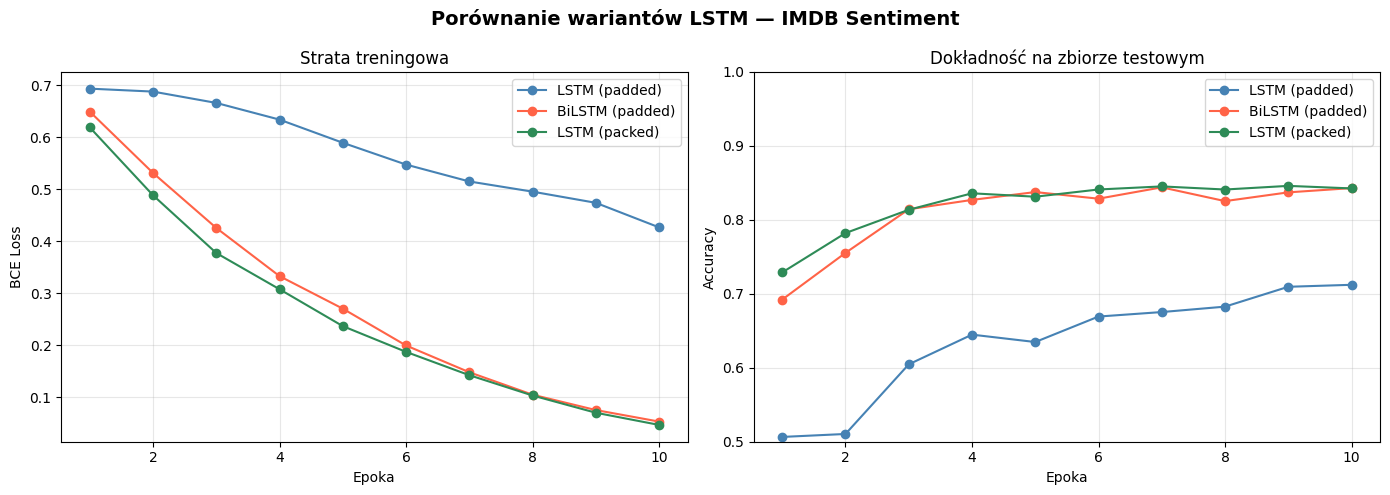


Test accuracies:
  LSTM (padded)            : 0.712
  BiLSTM (padded)          : 0.843
  LSTM (packed)            : 0.842


In [14]:
print("=" * 50)
print("1. LSTM z paddingiem")
m1 = LSTMNet(input_size=EMBED_DIM, hidden_size=HIDDEN,
             embed=True, vocab_size=VOCAB_SIZE)
results['LSTM (padded)'] = train_model(
    m1, train_loader_pad, test_loader_pad,
    epochs=EPOCHS, use_packed=False, device=DEVICE
)

print("=" * 50)
print("2. Bidirectional LSTM z paddingiem")
m2 = LSTMNet(input_size=EMBED_DIM, hidden_size=HIDDEN,
             embed=True, vocab_size=VOCAB_SIZE, bidirectional=True)
results['BiLSTM (padded)'] = train_model(
    m2, train_loader_pad, test_loader_pad,
    epochs=EPOCHS, use_packed=False, device=DEVICE
)

print("=" * 50)
print("3. LSTM z PackedSequence")
m3 = LSTMNet(input_size=EMBED_DIM, hidden_size=HIDDEN,
             embed=True, vocab_size=VOCAB_SIZE, packed=True)
results['LSTM (packed)'] = train_model(
    m3, train_loader_pack, test_loader_pack,
    epochs=EPOCHS, use_packed=True, device=DEVICE
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'tomato', 'seagreen']
xs = range(1, EPOCHS + 1)

for (name, hist), color in zip(results.items(), colors):
    axes[0].plot(xs, hist['train_loss'], label=name, color=color, marker='o')
    axes[1].plot(xs, hist['test_acc'],  label=name, color=color, marker='o')

axes[0].set_title('Strata treningowa')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Dokładność na zbiorze testowym')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Porównanie wariantów LSTM — IMDB Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTest accuracies:")
for name, hist in results.items():
    print(f"  {name:25s}: {hist['test_acc'][-1]:.3f}")


## Zadanie 2b — InsectWingbeat (klasyfikacja wieloklasowa)

Powtarzamy eksperyment na zbiorze InsectWingbeat. Tym razem dane wejściowe to surowe szeregi czasowe (brak warstwy embeddingu), a zadanie to klasyfikacja wieloklasowa (10 gatunków owadów). Używamy `CrossEntropyLoss` zamiast `BCEWithLogitsLoss`.

1. LSTM z paddingiem — InsectWingbeat
Epoch 1/30 | loss: 1.3645 | train acc: 0.488 | test acc: 0.603
Epoch 2/30 | loss: 0.9255 | train acc: 0.632 | test acc: 0.627
Epoch 3/30 | loss: 0.8359 | train acc: 0.666 | test acc: 0.640
Epoch 4/30 | loss: 0.7768 | train acc: 0.690 | test acc: 0.649
Epoch 5/30 | loss: 0.7321 | train acc: 0.707 | test acc: 0.658
Epoch 6/30 | loss: 0.6978 | train acc: 0.721 | test acc: 0.648
Epoch 7/30 | loss: 0.6677 | train acc: 0.734 | test acc: 0.656
Epoch 8/30 | loss: 0.6378 | train acc: 0.745 | test acc: 0.657
Epoch 9/30 | loss: 0.6126 | train acc: 0.755 | test acc: 0.655
Epoch 10/30 | loss: 0.5890 | train acc: 0.765 | test acc: 0.655
Epoch 11/30 | loss: 0.5678 | train acc: 0.775 | test acc: 0.654
Epoch 12/30 | loss: 0.5478 | train acc: 0.785 | test acc: 0.654
Epoch 13/30 | loss: 0.5301 | train acc: 0.792 | test acc: 0.652
Epoch 14/30 | loss: 0.5120 | train acc: 0.800 | test acc: 0.652
Epoch 15/30 | loss: 0.4956 | train acc: 0.806 | test acc: 0.654
Epoch 16/30

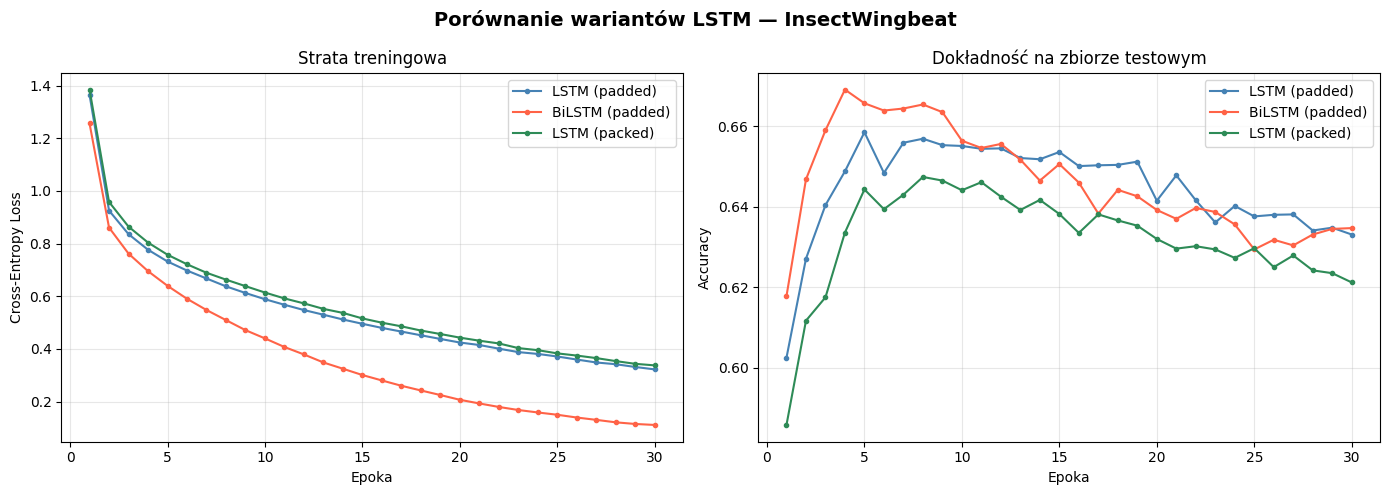

Test accuracies (InsectWingbeat):
  LSTM (padded)            : 0.633
  BiLSTM (padded)          : 0.635
  LSTM (packed)            : 0.621


In [16]:
INSECT_EPOCHS = 30
INSECT_INPUT_SIZE = X_train_i.shape[2]
N_INSECT_CLASSES = len(le.classes_)
INSECT_HIDDEN = 64
insect_results = {}

print("=" * 50)
print("1. LSTM z paddingiem — InsectWingbeat")
mi1 = LSTMNet(input_size=INSECT_INPUT_SIZE, hidden_size=INSECT_HIDDEN,
              num_classes=N_INSECT_CLASSES, embed=False)
insect_results['LSTM (padded)'] = train_model(
    mi1, insect_loader_pad, insect_test_pad,
    epochs=INSECT_EPOCHS, use_packed=False, binary=False, device=DEVICE
)

print("=" * 50)
print("2. Bidirectional LSTM z paddingiem — InsectWingbeat")
mi2 = LSTMNet(input_size=INSECT_INPUT_SIZE, hidden_size=INSECT_HIDDEN,
              num_classes=N_INSECT_CLASSES, embed=False, bidirectional=True)
insect_results['BiLSTM (padded)'] = train_model(
    mi2, insect_loader_pad, insect_test_pad,
    epochs=INSECT_EPOCHS, use_packed=False, binary=False, device=DEVICE
)

print("=" * 50)
print("3. LSTM z PackedSequence — InsectWingbeat")
mi3 = LSTMNet(input_size=INSECT_INPUT_SIZE, hidden_size=INSECT_HIDDEN,
              num_classes=N_INSECT_CLASSES, embed=False, packed=True)
insect_results['LSTM (packed)'] = train_model(
    mi3, insect_loader_pack, insect_test_pack,
    epochs=INSECT_EPOCHS, use_packed=True, binary=False, device=DEVICE
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'tomato', 'seagreen']
xs = range(1, INSECT_EPOCHS + 1)

for (name, hist), color in zip(insect_results.items(), colors):
    axes[0].plot(xs, hist['train_loss'], label=name, color=color, marker='o', markersize=3)
    axes[1].plot(xs, hist['test_acc'],  label=name, color=color, marker='o', markersize=3)

axes[0].set_title('Strata treningowa')
axes[0].set_xlabel('Epoka'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Dokładność na zbiorze testowym')
axes[1].set_xlabel('Epoka'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Porównanie wariantów LSTM — InsectWingbeat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Test accuracies (InsectWingbeat):")
for name, hist in insect_results.items():
    print(f"  {name:25s}: {hist['test_acc'][-1]:.3f}")


# Zadanie 3

Dla modelu językowego, dokonaj wizualizacji embeddingów 10 przykładowych słów. Dobierz słowa samodzielnie tak, aby pokazać, że embedding częściowo (ale prwadopodobnie nie idealnie) oddają relacje semantyczne. Możesz wykorzystać gotowe metody redukcji wymiarowości np. z scikit-learn aby umieścić embeddingi w przestrzeni dwuwymiarowej.

Ponieważ zbiór pobierany z tf.keras jest już reprezentowany w postaci list liczb całkowitych, bedziesz korzystać ze słownika indeksów również dostępnego w tf.keras:

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


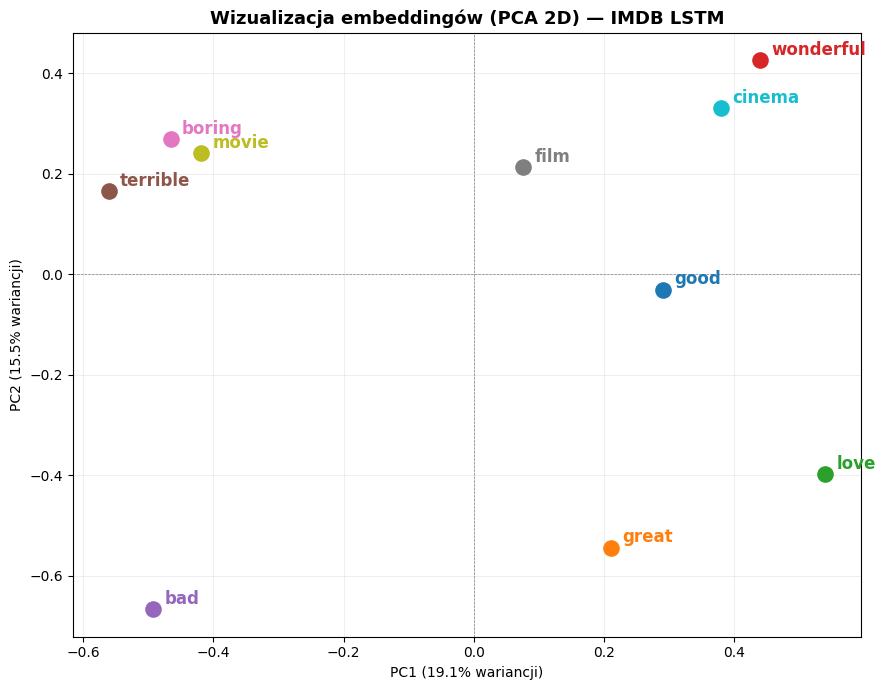

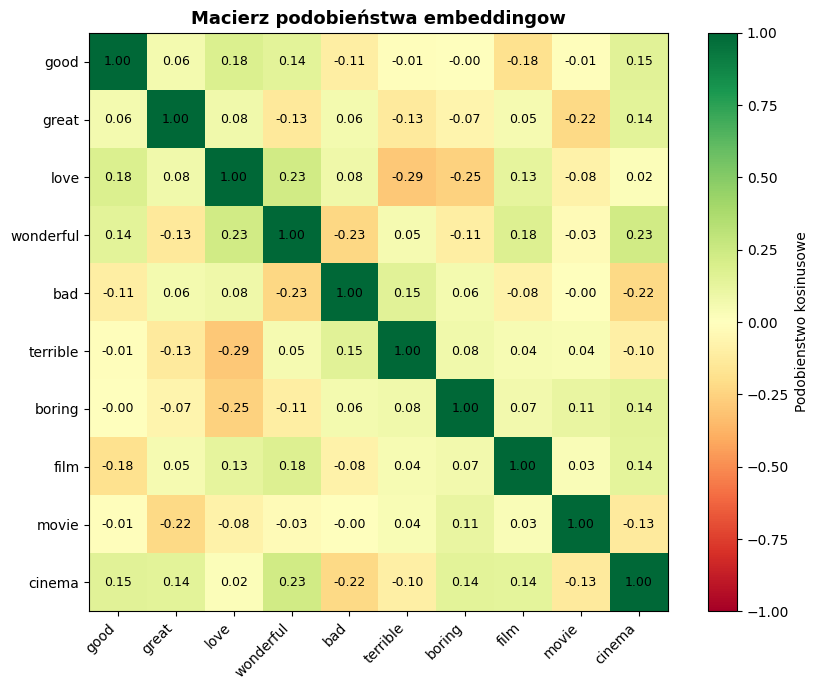

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

word_idx = imdb.get_word_index(path='imdb_word_index.json')
idx_to_word = {v + 3: k for k, v in word_idx.items()}

WORDS = [
    "good", "great", "love", "wonderful",
    "bad", "terrible", "boring",
    "film", "movie", "cinema",
]

embedding_matrix = m1.embedding.weight.detach().cpu().numpy()

word_indices = {w: word_idx[w] + 3 for w in WORDS if w in word_idx}
valid_words  = [w for w in WORDS if w in word_indices]
vecs = np.array([embedding_matrix[word_indices[w]] for w in valid_words])

pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(normalize(vecs))

fig, ax = plt.subplots(figsize=(9, 7))
colors_emb = plt.cm.tab10(np.linspace(0, 1, len(valid_words)))

for i, (word, (x, y)) in enumerate(zip(valid_words, vecs_2d)):
    ax.scatter(x, y, color=colors_emb[i], s=120, zorder=3)
    ax.annotate(word, (x, y), textcoords='offset points',
                xytext=(8, 4), fontsize=12, color=colors_emb[i], fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Wizualizacja embeddingów (PCA 2D) — IMDB LSTM', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% wariancji)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% wariancji)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(normalize(vecs))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(valid_words))); ax.set_xticklabels(valid_words, rotation=45, ha='right')
ax.set_yticks(range(len(valid_words))); ax.set_yticklabels(valid_words)
plt.colorbar(im, ax=ax, label='Podobienstwo kosinusowe')
ax.set_title('Macierz podobieństwa embeddingow', fontsize=13, fontweight='bold')
for i in range(len(valid_words)):
    for j in range(len(valid_words)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='black')
plt.tight_layout()
plt.show()